   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

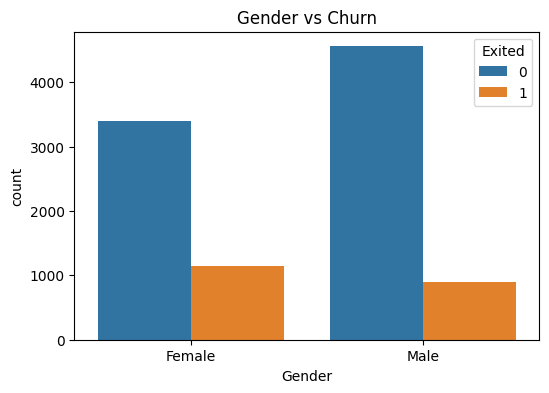

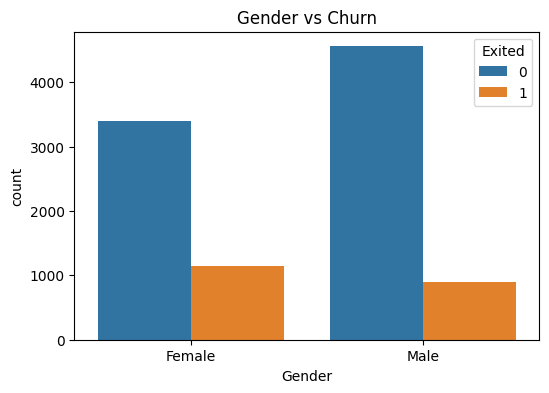

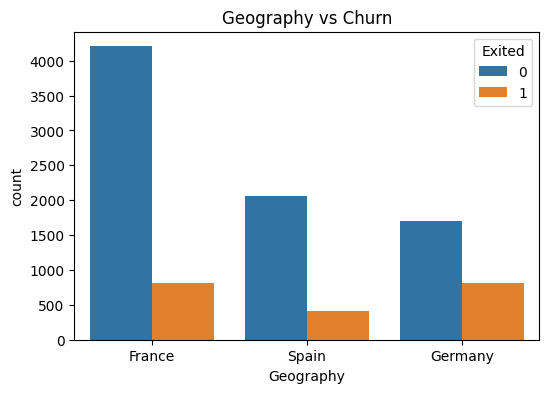

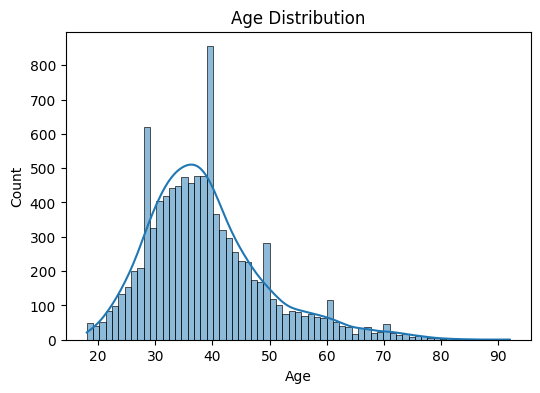

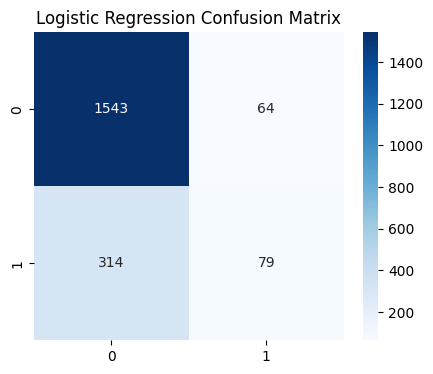

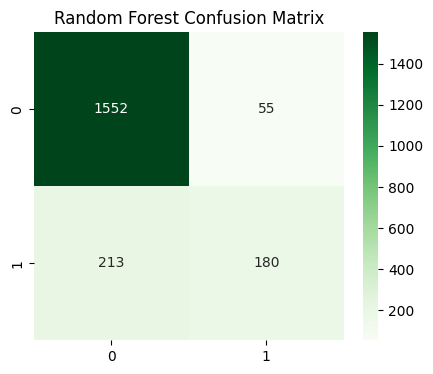

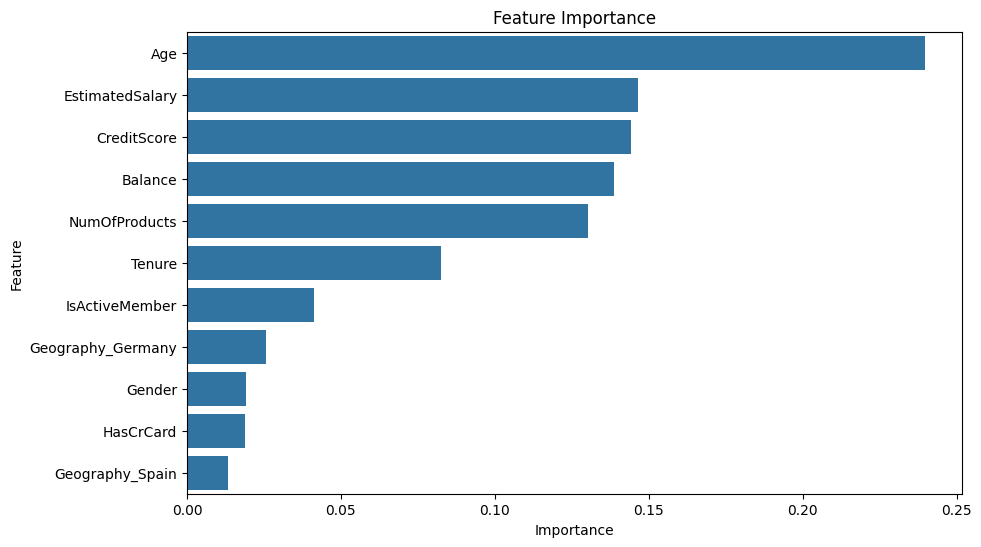


Feature Importance:

              Feature  Importance
2                 Age    0.239783
8     EstimatedSalary    0.146638
0         CreditScore    0.144214
4             Balance    0.138613
5       NumOfProducts    0.130255
3              Tenure    0.082427
7      IsActiveMember    0.041110
9   Geography_Germany    0.025711
1              Gender    0.019258
6           HasCrCard    0.018722
10    Geography_Spain    0.013268

=== Logistic Regression ===
Accuracy: 0.811
MAE: 0.189
RMSE: 0.43474130238568315

=== Random Forest ===
Accuracy: 0.866
MAE: 0.134
RMSE: 0.36606010435446257


In [ ]:
# -----------------------------
# Introduction
# -----------------------------
# This project predicts whether bank customers are likely to leave the bank.

# -----------------------------
# Problem Statement
# -----------------------------
# The objective is to predict customer churn using customer demographic and banking information.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,mean_absolute_error, mean_squared_error,mean_squared_error


# --------------------
# Dataset Description
# --------------------
# The dataset contains customer banking information and have 10000 records with 14 features.
# Target Variable:
# Exited
# 0 = Customer Stayed
# 1 = Customer Left

df = pd.read_csv("Churn_Modelling.csv")
df_eda = df.copy()
feature_df = df.copy()

print(df.head())
print("\nShape of Dataset:", df.shape)
print("\nColumns:\n", df.columns)

print("\nDataset Info:")
df.info()

# -----------------------------
# Data Cleaning and Preparation
# -----------------------------

# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Remove unnecessary columns
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

# -----------------------------
# Encoding Categorical Features
# -----------------------------

# Label Encoding for Gender
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot Encoding for Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True, dtype=int)

print(df.head())


# -----------------------------
# Data Visualization
# -----------------------------
# Exploratory Data Analysis (EDA)
# We visualize key features to understand data distribution and relationships.

# Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Exited', data=df_eda)
plt.title("Gender vs Churn")
plt.show()

# Gender vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Exited', data=df_eda)
plt.title("Gender vs Churn")
plt.show()

# Geography vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x='Geography', hue='Exited', data=df_eda)
plt.title("Geography vs Churn")
plt.show()

# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

# -----------------------------
# Feature Selection
# -----------------------------

X = df.drop('Exited', axis=1)

y = df['Exited']

# -----------------------------
# Feature Scaling
# -----------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# -----------------------------
# Train-Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

# -----------------------------
# Model Training and Testing
# -----------------------------
# Two models are used:
# 1. Logistic Regression
# 2. Random Forest Classifier

# =========================================================
# MODEL 1: LOGISTIC REGRESSION
# =========================================================

lr_model = LogisticRegression(max_iter=2000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

# Confusion Matrix
lr_cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()


# =========================================================
# MODEL 2: RANDOM FOREST
# =========================================================

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

# -----------------------------
# Feature Importance Analysis
# -----------------------------
# This helps identify which features influence customer churn the most.

importance = rf_model.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({'Feature': feature_names,'Importance': importance})

feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',data=feature_df)

plt.title("Feature Importance")
plt.show()

print("\nFeature Importance:\n")
print(feature_df)



# -----------------------------
# Model Evaluation Metrics
# -----------------------------

# Evaluation for Model 1(Logistic Regression)

print("\n=== Logistic Regression ===")

print("Accuracy:", accuracy_score(y_test, lr_pred))

print("MAE:", mean_absolute_error(y_test, lr_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))


# Evaluation for Model 2 (Random Forest)

print("\n=== Random Forest ===")

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("MAE:", mean_absolute_error(y_test, rf_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

# -----------------------------
# Conclusion
# -----------------------------
# In this project, machine learning models were used to predict
# customer churn in a banking dataset.

# Logistic Regression and Random Forest models were trained
# and evaluated using accuracy, confusion matrix, MAE, RMSE

# Random Forest performed better and also provided feature importance analysis.